# Polarizzazione in inversa di un fotodiodo
A cura di Giovanni N. D'Aloisio, matricola 494722, A.A. 2022-23.

## Introduzione

Esponendo un semiconduttore alla radiazione elettromagnetica, se l’energia del singolo fotone $E = hν = hc/ \lambda$ è maggiore del gap $E_g$ del semiconduttore,  è possibile che il fotone venga assorbito dando origine ad una coppia elettrone-lacuna. Questo significa un elettrone in più in banda di conduzione ed una lacuna in più in banda di valenza. Si ha quindi una variazione nel numero di portatori (sia elettroni che lacune, simultaneamente) che partecipano sia ai moti diffusivi che di deriva (in presenza di un campo elettrico).

La risposta di un diodo illuminato (o fotodiodo) è descritta dalla legge:

$$I = I_0 (e^{\frac{qV}{kT}}- 1)-I_{ph}$$

Dove:  
- $q=1.602 \cdot 10^{-19}C$ è la carica dell'elettrone,
- $k = 1.380 \cdot 10^{-23} J/K$ è la costante di bolzmann,
- $T$ è temperatura in kelvin dell'ambiente di lavoro,
- $V$ è il potenziale ai capi del diodo,
- $I$ è la corrente nel diodo,
- $I_0$ è la corrente di saturazione del diodo,
- $I_{ph}$ è la corrente prodotta dall'esposizione della radiazione elettromagnetica.

Risulta $I_{ph}$ proporzionale al numero di fotoni assorbiti, provenienti in questo caso dal LED accoppiato, secondo la legge:

$$I_{ph} = \beta \ I_{LED}$$

## Scopo dell'esperienza
L'esperienza ha come scopo principale quello di valutare il funzionamento di un accoppiamento LED-fotodiodo, con il primo collegato in configurazione a polarizzazione diretta.

## Strumentazione

Per raggiungere gli obiettivi della prova, si dispone di:
+ LED;
+ fotodiodo;
+ 2 tester (amperometro e voltmetro);
+ alimentatore in corrente continua;
+ breadboard;
+ resistenze di diverso valore;
+ trimmer.

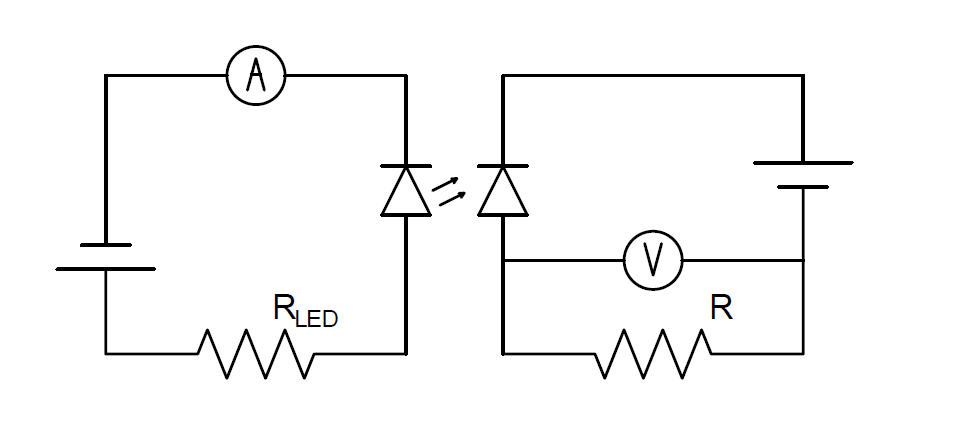

## Procedura sperimentale

Il circuito relativo al fotodiodo può essere analizzato considerando la corrente $I_D = I_R=-V_R/R \ $ che scorre sia nel fotodiodo che nella resistenza.
Assumendo per positivi il potenziale $V_D=V_R+V_g \ $ e la corrente oraria, il potenziale del generatore è applicato in modo da invertire la polarizzazione sul diodo, e la corrente sulla resistenza scorre dal polo positivo a quello negativo.

Al variare dell’illuminazione, la corrente fotogenerata fa traslare la curva che descrive la risposta del fotodiodo verso i valori negativi; inoltre, la regione di lavoro si trova in una zona per cui la tensione misurata è direttamente proporzionale alla corrente fotogenerata.

Risulta dunque:

$$I_{ph} = I_0 \Bigg( \exp \Bigg( \frac{q (V_R + V_g)}{kT} \Bigg) -1 \Bigg) + \frac{V_R}{R}$$

Vengono dunque catturati i dati di tensione ai capi del fotodiodo e di corrente che scorre nel LED per più valori di tensione applicata a quest'ultimo.

## Importazione e analisi dei dati sperimentali

Di seguito sono riportati gli snippets utilizzati per l'analisi dei dati.

Su [GitHub](https://github.com/nikitodos/UniPV_Physics_Lab_3/tree/main/02_LED_PD_INVERSE_COUPLING) è possibile visualizzare  i dati raccolti in formato tabulato.

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
from scipy import constants as scc
import matplotlib.pyplot as plt
import pandas as pd

# Definisci costanti fisiche utili

electron_charge = scc.e
Boltzmann = scc.Boltzmann
temperature = 300
resistance3 = 20000

# Definisci funzione di fit per V che va a meno infinito

def funzione3(V,beta):
    I=V/(resistance3*beta)
    return I

# Importa i dati

filename = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/02_LED_PD_INVERSE_COUPLING/INVERSE_20000_OHM.CSV'

data = pd.read_csv(filename)

# Converto i dati in numpy arrays, usando unità del S.I.

V00=data['Tensione PD (LED 0 V) (mV)'].to_numpy()*0.001
V02=data['Tensione PD (LED 0.2 V) (mV)'].to_numpy()*0.001
V05=data['Tensione PD (LED 0.5 V) (mV)'].to_numpy()*0.001
V20=data['Tensione PD (LED 2 V) (mV)'].to_numpy()*0.001
I=data['Corrente LED (mA)'].to_numpy()*0.001

print('Importazione dei dati completata.')

Importazione dei dati completata.


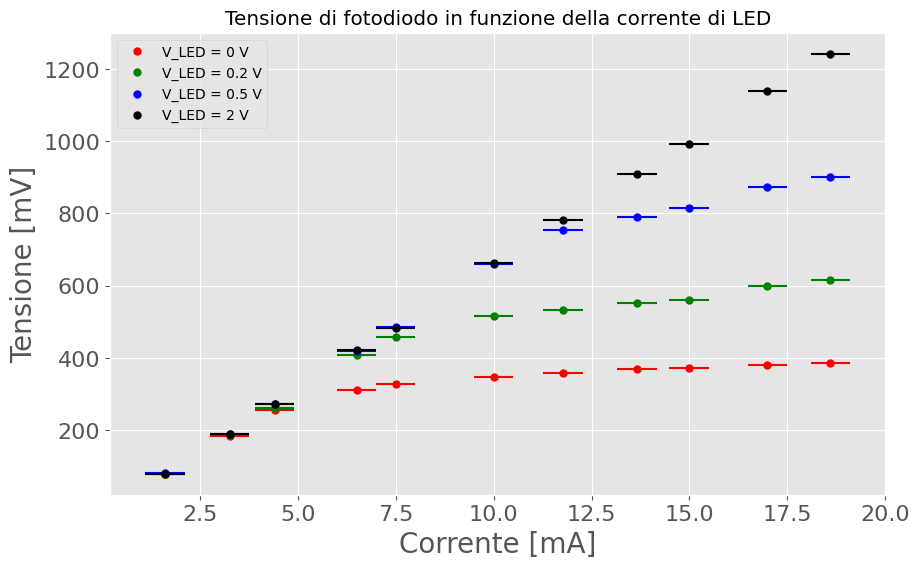

In [ ]:
# Plot con approccio "fisico"

plt.figure(figsize=[10,6])
plt.title('Tensione di fotodiodo in funzione della corrente di LED')
plt.ylabel('Tensione [mV]', fontsize=20)
plt.xlabel('Corrente [mA]', fontsize=20)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.grid(True)
plt.errorbar(I*1000,V00*1000,yerr=0.0005,xerr=0.5,color='r',linestyle="")
plt.plot(I*1000,V00*1000,'o',color='r', label="V_LED = 0 V",markersize=5)
plt.errorbar(I*1000,V02*1000,yerr=0.0005,xerr=0.5,color='g',linestyle="")
plt.plot(I*1000,V02*1000,'o',color='g', label="V_LED = 0.2 V",markersize=5)
plt.errorbar(I*1000,V05*1000,yerr=0.0005,xerr=0.5,color='b',linestyle="")
plt.plot(I*1000,V05*1000,'o',color='b', label="V_LED = 0.5 V",markersize=5)
plt.errorbar(I*1000,V20*1000,yerr=0.0005,xerr=0.5, color='k',linestyle="")
plt.plot(I*1000,V20*1000,'o',color='k', label="V_LED = 2 V",markersize=5)
plt.style.use("ggplot")
plt.legend()

 
Fit con i dati a V_LED = 2 V
Beta_fit = ( 3.32e-03  ±  6.7e-05 ) 
 
Fit con i dati a V_LED = 0 V
Corrente inversa di saturazione: I0_fit = ( 1.23e-09 ± 1.2e-09 ) A
Parametro di idealità:           n_fit  = ( 1.43e+00 ± 1.4e-01 ) 
 
Fit con i dati a V_LED = 0.2 V
Corrente inversa di saturazione: I0_fit = ( 2.47e-07 ± 8.e-07  ) A
Parametro di idealità:           n_fit  = ( 5.e+00   ± 3.6e+00 ) 
 
Fit con i dati a V_LED = 0.5 V
Corrente inversa di saturazione: I0_fit = ( 1.94e-08 ± 1.1e-07 ) A
Parametro di idealità:           n_fit  = ( 5.e+00   ± 4.3e+00 ) 
 


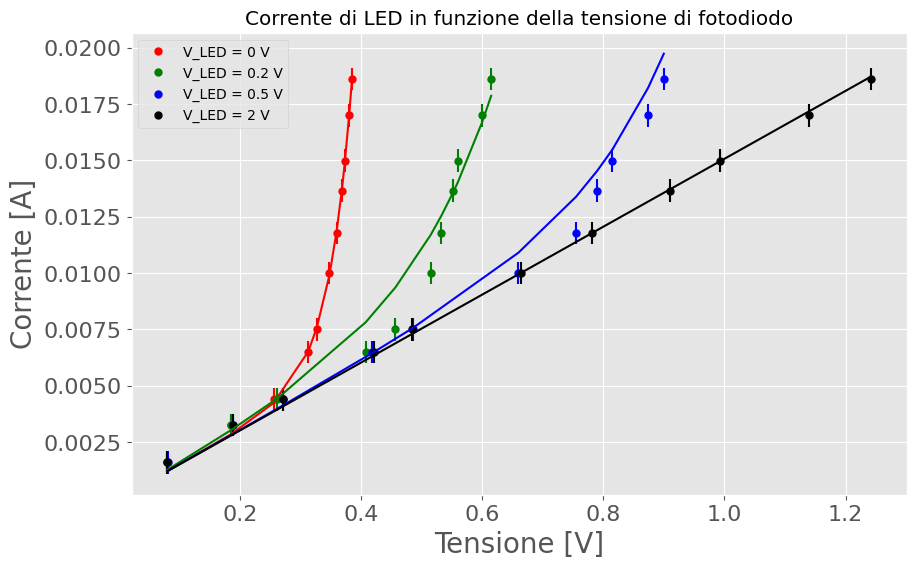

In [ ]:
# Fit dei dati

# Parte generica

ndata=len(I)
I0_min, I0_max = 0.00000000000001, 1
n_min, n_max = 1, 5
min, max = [I0_min, n_min], [I0_max, n_max]
bounds = [min, max]

# Fit con dati a V_LED = 2 V

popt_20, pcov_20=sop.curve_fit(funzione3, V20, I)
beta_fit_20 = popt_20[0]   # questo è il valore di beta che risulta dal fit
sigma_20 = np.sqrt(ndata*np.diag(pcov_20))

print(' ')

print('Fit con i dati a V_LED = 2 V')

print('Beta_fit = (', np.format_float_scientific(beta_fit_20,precision=2), ' ± ',np.format_float_scientific(sigma_20[0], precision=1), ') ')

print(' ')

# Definisci funzione di fit per valori bassi di Vg (assumendo esatto il valore beta_fit_20)

def funzione2(V,I0,n):
    I=(1/beta_fit_20)*(I0*(np.exp(electron_charge*V/(n*Boltzmann*temperature))-1)+(V/resistance3))
    return I

# Fit con dati a V_LED = 0 V

popt_00, pcov_00=sop.curve_fit(funzione2, V00, I, bounds=bounds)
I0_fit_00 = popt_00[0]   # questo è il valore di I0 che risulta dal fit
n_fit_00 = popt_00[1]   # questo è il valore di n che risulta dal fit
sigma_00 = np.sqrt(ndata*np.diag(pcov_00))

print('Fit con i dati a V_LED = 0 V')
print('Corrente inversa di saturazione: I0_fit = (', np.format_float_scientific(I0_fit_00,precision=2), '±',np.format_float_scientific(sigma_00[0], precision=1), ') A')
print('Parametro di idealità:           n_fit  = (', np.format_float_scientific(n_fit_00,precision=2), '±',np.format_float_scientific(sigma_00[1], precision=1), ') ')

# Fit con dati a V_LED = 0.2 V

popt_02, pcov_02=sop.curve_fit(funzione2, V02, I, bounds=bounds)
I0_fit_02 = popt_02[0]   # questo è il valore di I0 che risulta dal fit
n_fit_02 = popt_02[1]   # questo è il valore di n che risulta dal fit
sigma_02 = np.sqrt(ndata*np.diag(pcov_02))

print(' ')

print('Fit con i dati a V_LED = 0.2 V')
print('Corrente inversa di saturazione: I0_fit = (', np.format_float_scientific(I0_fit_02, precision=2), '±',np.format_float_scientific(sigma_02[0], precision=1), ' ) A')
print('Parametro di idealità:           n_fit  = (', np.format_float_scientific(n_fit_02, precision=2), '  ±',np.format_float_scientific(sigma_02[1], precision=1), ') ')

# Fit con dati a V_LED = 0.5 V

popt_05, pcov_05=sop.curve_fit(funzione2, V05, I, bounds=bounds)
I0_fit_05 = popt_05[0]   # questo è il valore di I0 che risulta dal fit
n_fit_05 = popt_05[1]   # questo è il valore di n che risulta dal fit
sigma_05 = np.sqrt(ndata*np.diag(pcov_05))

print(' ')

print('Fit con i dati a V_LED = 0.5 V')
print('Corrente inversa di saturazione: I0_fit = (', np.format_float_scientific(I0_fit_05, precision=2), '±',np.format_float_scientific(sigma_05[0], precision=1), ') A')
print('Parametro di idealità:           n_fit  = (', np.format_float_scientific(n_fit_05, precision=2), '  ±',np.format_float_scientific(sigma_05[1], precision=1), ') ')

print(' ')


# Plot dati fittati più dati reali, con approccio "statistico"

plt.figure(figsize=[10,6])
plt.title('Corrente di LED in funzione della tensione di fotodiodo')
y_00=funzione2(V00,I0_fit_00,n_fit_00)
y_02=funzione2(V02,I0_fit_02,n_fit_02)
y_05=funzione2(V05,I0_fit_05,n_fit_05)
y_20=funzione3(V20,beta_fit_20)
plt.xlabel('Tensione [V]', fontsize=20)
plt.ylabel('Corrente [A]', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(V00,I,xerr=0.0005,yerr=0.0005,color='r',linestyle="")
plt.plot(V00,I,'o',color='r', label="V_LED = 0 V",markersize=5)
plt.errorbar(V02,I,xerr=0.0005,yerr=0.0005,color='g',linestyle="")
plt.plot(V02,I,'o',color='g', label="V_LED = 0.2 V",markersize=5)
plt.errorbar(V05,I,xerr=0.0005,yerr=0.0005,color='b',linestyle="")
plt.plot(V05,I,'o',color='b', label="V_LED = 0.5 V",markersize=5)
plt.errorbar(V20,I,xerr=0.0005,yerr=0.0005,color='k',linestyle="")
plt.plot(V20,I,'o',color='k', label="V_LED = 2 V",markersize=5)
plt.plot(V00,y_00,color='red',linestyle="solid")
plt.plot(V02,y_02,color='green',linestyle="solid")
plt.plot(V05,y_05,color='blue',linestyle="solid")
plt.plot(V20,y_20,color='black',linestyle="solid")
plt.style.use("ggplot")
plt.legend()

## Discussione dei risultati e conclusioni

Dal diagramma di $V_R$ in funzione di $I_{ph}$ emerge che, con $V_g << 0$, la corrente di buio nel diodo, vale a dire la corrente associabile al rumore ambientale, è trascurabile, ottenendo $V_R = R \ I_{ph}$; la tensione misurata è direttamente proporzionale alla corrente fotogenerata, e
il fotodiodo opera in modalità lineare o fotoconduttiva.

Con $V_g = 0$, la corrente di buio del diodo si sottrae alla fotocorrente e $V_R$ è inferiore al caso di polarizzazione inversa. Si ritrova quindi la curva di carico della cella solare vista nell'introduzione.

All’aumentare della fotocorrente, la tensione sulla resistenza tende alla tensione di circuito aperto $V_ {oc} = \frac{kT}{q} \ \ln \Big( \frac{I_{ph}}{I_0} -1 \Big)$, e cresce logaritmicamente con $I_{ph}$. In questo caso il fotodiodo opera in modalità fotovoltaica.

Il fatto che $V_R$ sia anche nel secondo membro dell'equazione della corrente non consente di utilizzare lo stesso approccio per il fit dei dati. Per fittare i dati si scrive $I_{ph}$ in funzione di $V_R$, introducendo il fattore di idealità n, che tipicamente è compreso fra 1 e 5 ed è legato ai processi di ricombinazione nonradiativa nel diodo.

Seguendo questo secondo approccio, in assenza di polarizzazione ($V_g$ = 0) si ha la somma della retta $^{V_R}/_R$ e della caratteristica del diodo. All’aumentare della polarizzazione inversa, una maggiore porzione della curva giace sulla retta $^V/_R$. Per grande polarizzazione inversa, invece, tutta la curva coincide con la retta $^{V_R}/_R$.

Per i risultati raggiunti, nonché i valori ottenuti dal fit dei dati sperimentali, si ritiene che gli scopi della prova siano stati raggiunti con successo.